In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

from matplotlib import patches

from youngs_modulus_utils import *

torch.manual_seed(67)

In [3]:
class NN(torch.nn.Module):
    def __init__(self, input_dim, output_dim, layers, neurons, activation = 'tanh'):
        super(NN, self).__init__()
        self.activation = activation

        self.input_layer   = torch.nn.Linear(input_dim, neurons, bias = True)
        self.hidden_layers = torch.nn.ModuleList([torch.nn.Linear(neurons, neurons, bias = True) for _ in range(layers)])
        self.output_layer_u  = torch.nn.Linear(neurons, output_dim, bias = True)
        self.output_layer_E  = torch.nn.Linear(neurons, output_dim, bias = True)
        
        if self.activation == 'tanh':
            self.act = nn.Tanh()
        elif self.activation == 'relu':
            self.act = nn.ReLU()
        elif self.activation == 'gelu':
            self.act = nn.GELU()
        elif self.activation == 'sin':
            self.act = torch.sin  
        else:
            raise ValueError(f"Unknown activation: {activation}")
    
    def forward(self, x):
        a =  self.input_layer(x)
        for l in self.hidden_layers:
            a = self.act(l(a))
        return self.output_layer_u(a), torch.nn.functional.softplus(self.output_layer_E(a))
    
    
    def init_xavier(self):
        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                if self.activation == 'sin':
                    nn.init.xavier_uniform_(m.weight)
                else:
                    g = nn.init.calculate_gain(self.activation)
                    torch.nn.init.xavier_uniform_(m.weight, gain=g)
                m.bias.data.fill_(0)
        self.apply(init_weights)

    def init_siren(self):
        for i, m in enumerate(self.modules()):
            if isinstance(m, nn.Linear):
                in_dim = m.weight.size(1)

                if i == 1:  # first layer
                    m.weight.data.uniform_(-1/in_dim, 1/in_dim)
                else:
                    m.weight.data.uniform_(-np.sqrt(6/in_dim)/30, np.sqrt(6/in_dim)/30)

                m.bias.data.fill_(0)

sum(p.numel() for p in NN(5, 5, 5, 5).parameters())

240

In [4]:
BATCH_SIZE = 32

In [5]:
domain = torch.tensor([[0, 1], [0, 2]]) # x = [0, 1]; t = [0, 2]
sobol_engine = torch.quasirandom.SobolEngine(dimension = 2) # x and t

class dataset(torch.utils.data.Dataset):
    def __init__(self, engine: torch.quasirandom.SobolEngine, draw: int):
        self.data = engine.draw(draw) 

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index]
    
train_dataset_obj = dataset(sobol_engine, 1000)
train_dataloader = torch.utils.data.DataLoader(train_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

test_dataset_obj = dataset(sobol_engine, 500)
test_dataloader = torch.utils.data.DataLoader(test_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

next(iter(test_dataloader)).shape

torch.Size([32, 2])

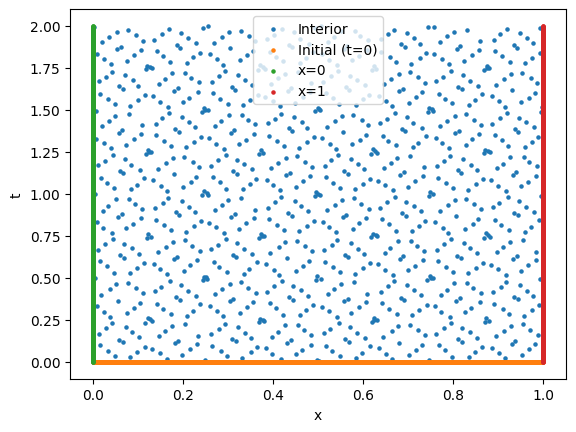

In [6]:
domain = torch.tensor([[0, 1], [0, 2]]) # x = [0, 1]; t = [0, 2]
sobol_engine = torch.quasirandom.SobolEngine(dimension = 2) # x and t

def u_0(x):
    return torch.sin(5*x) + torch.sin(10*x) #+ torch.exp(x)

def v_0(x):
    return torch.cos(10*x)# + torch.exp(-x)
    
def get_interior(data, domain):
    data = data.clone()
    data[:, 0] =  domain[0][0] + (domain[0][1] - domain[0][0]) * data[:, 0]
    data[:, 1] =  domain[1][0] + (domain[1][1] - domain[1][0]) * data[:, 1]
    return data

def get_BC(data, domain):
    data = data.clone()
    data[:,1] = domain[1][0] + (domain[1][1] - domain[1][0]) * data[:,1]

    # x = 0
    data_0 = data.clone()
    data_0[:,0] = domain[0][0]

    # x = L
    data_L = data.clone()
    data_L[:,0] = domain[0][1]

    return data_0, data_L

def get_initial(data, domain, u_0, v_0):
    data = data.clone()
    data[:,0] = domain[0][0] + (domain[0][1] - domain[0][0]) * data[:,0]

    data[:, 1] = 0 # t = 0 

    x = data[:,0]
    u = u_0(x)
    u_t = v_0(x)

    u = torch.stack((u, torch.zeros_like(u)), dim=1)
    u_t = torch.stack((u_t, torch.zeros_like(u_t)), dim=1)

    return data, u, u_t


# plotting
dummy_data = []

for d in train_dataloader:
    dummy_data.append(d)
    
data = torch.cat(dummy_data, dim = 0)

interior = get_interior(data, domain)
ic_coords, _, _ = get_initial(data, domain, u_0, v_0)
bc_0, bc_L = get_BC(data, domain)

plt.figure()
plt.scatter(interior[:,0], interior[:,1], s=5, label="Interior")
plt.scatter(ic_coords[:,0], ic_coords[:,1], s=5, label="Initial (t=0)")

plt.scatter(bc_0[:,0], bc_0[:,1], s=5, label="x=0")
plt.scatter(bc_L[:,0], bc_L[:,1], s=5, label="x=1")

plt.legend()
plt.xlabel("x")
plt.ylabel("t")
plt.show()

In [7]:
# interior_data = get_interior(sobol_engine, 10)

def get_interior_residual(model, points):
    points.requires_grad_(True)

    u, E = model(points)

    grad_u = torch.autograd.grad(u.sum(), points, create_graph=True)[0]
    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]

    u_tt = torch.autograd.grad(u_t.sum(), points, create_graph=True)[0][:, 1]

    # flux = E(u_x) * u_x
    flux = E * u_x

    flux_x = torch.autograd.grad(
        flux.sum(), points, create_graph=True
    )[0][:, 0]

    interior_residual = u_tt - flux_x

    return interior_residual

def get_IC_residue(model, points):

    coords  = points[0].clone().detach().requires_grad_(True) # (x, 0)
    u_0     = points[1].clone().detach().requires_grad_(True) # u(x,0)
    u_t     = points[2].clone().detach().requires_grad_(True) # u_t(x,0)

    u_pred, E_pred = model(coords) 
    ic_1_residue = u_pred - u_0

    grad_u = torch.autograd.grad(
        u_pred.sum(), coords, create_graph=True
    )[0]
    u_t_pred = grad_u[:, 1].unsqueeze(1)
    ic_2_residue = u_t_pred - u_t
    return ic_1_residue, ic_2_residue

def get_BC_residue(model, points):
    return model(points[0])[0],  model(points[1])[0]

In [8]:
def train(epochs, optimizer, 
          predictor_model, 
          train_dataloader, test_dataloader, 
          get_interior, get_initial, get_BC,
          get_interior_residual, get_IC_residue, get_BC_residue, 
          domain,
          u_0, v_0,
          lr_annealing_decay = None, initial_lr = 1e-3, lambda_scaling: bool = False):
    
    epoch_loss_track = []
    epoch_loss_track_test = []
    residue_tracker = {}
    grad_tracker = {
        "pde": [],
        "ic": [],
        "bc": []
    }

    lambda_pde = 1
    lambda_ic = 1
    lambda_bc = 1
    lambda_tracker = {"pde": [], "ic": [], "bc": []}

    for epoch in range(epochs):

        residue_tracker[epoch] = []
        epoch_loss = 0
        epoch_loss_test = 0
        
        epoch_loss_PDE = 0
        epoch_loss_IC = 0
        epoch_loss_BC = 0

        g_pde_epoch = 0
        g_ic_epoch = 0
        g_bc_epoch = 0

        g_pdes = []
        g_ics = []
        g_bcs = []

        for train_data in train_dataloader:
            predictor_model.train()

            optimizer.zero_grad()
            interior_data   = get_interior(train_data, domain) 
            IC_data         = get_initial(train_data, domain, u_0, v_0) # u, u_t (exact at t = 0)
            BC_data         = get_BC(train_data, domain) # t at u = 0 and t at u = L


            interior_residue  = get_interior_residual(predictor_model, interior_data)
            IC_residue        = get_IC_residue(predictor_model, IC_data)
            BC_residue        = get_BC_residue(predictor_model, BC_data)

            loss_pde = torch.mean(interior_residue**2)
            loss_ic  = torch.mean((IC_residue[0]**2) + (IC_residue[1]**2))
            loss_bc  = torch.mean((BC_residue[0]**2) + (BC_residue[1]**2))

            # gradient mismatach
            models = [predictor_model]
            g_pde = grad_norm(loss_pde, models)
            g_ic  = grad_norm(loss_ic, models)
            g_bc  = grad_norm(loss_bc, models)

            g_pdes.append(g_pde)
            g_ics.append(g_ic)
            g_bcs.append(g_bc)

            g_pde_epoch += g_pde
            g_ic_epoch  += g_ic
            g_bc_epoch  += g_bc

            # total of iniduvidual residue
            epoch_loss_PDE += loss_pde
            epoch_loss_IC += loss_ic
            epoch_loss_BC += loss_bc

            # total
            if lambda_scaling:
                loss = (lambda_pde * loss_pde) + (lambda_ic * loss_ic) + (lambda_bc * loss_bc)
            else:
                lambda_pde, lambda_ic, lambda_bc = 1, 1, 1
                loss =  loss_pde +  loss_ic +  loss_bc

            epoch_loss += loss
            loss.backward()
            optimizer.step()

            grad_tracker["pde"].append(g_pde.item())
            grad_tracker["ic"].append(g_ic.item())
            grad_tracker["bc"].append(g_bc.item())

        # scaling lambda
        g_pde_mean = np.mean([g.item() for g in g_pdes])
        g_ic_mean  = np.mean([g.item() for g in g_ics])
        g_bc_mean  = np.mean([g.item() for g in g_bcs])
        g_max_mean = max(g_pde_mean, g_ic_mean, g_bc_mean)

        beta = 0.9
        # lambda_pde = beta * lambda_pde + (1 - beta) * (g_max_mean / (g_pde_mean + 1e-8))
        lambda_ic  = beta * lambda_ic  + (1 - beta) * (g_max_mean / (g_ic_mean  + 1e-8))
        lambda_bc  = beta * lambda_bc  + (1 - beta) * (g_max_mean / (g_bc_mean  + 1e-8))

        lambda_pde = float(np.clip(lambda_pde, 0.05, 100.0))
        lambda_ic  = float(np.clip(lambda_ic,  0.05, 100.0))
        lambda_bc  = float(np.clip(lambda_bc,  0.05, 100.0))

        if lambda_scaling:
            lambda_tracker["pde"].append(lambda_pde)
            lambda_tracker["ic"].append(lambda_ic)
            lambda_tracker["bc"].append(lambda_bc)
        else:
            lambda_tracker["pde"].append(1)
            lambda_tracker["ic"].append(1)
            lambda_tracker["bc"].append(1)

        residue_tracker[epoch].extend((epoch_loss_PDE.item()/len(train_dataloader), 
                                    epoch_loss_IC.item()/len(train_dataloader), 
                                    epoch_loss_BC.item()/len(train_dataloader)))

        for test_data in test_dataloader:
            
            predictor_model.eval()

            interior_data   = get_interior(test_data, domain) 
            IC_data         = get_initial(test_data, domain, u_0, v_0) # u, u_t (exact at t = 0)
            BC_data         = get_BC(test_data, domain) # t at u = 0 and t at u = L


            interior_residue  = get_interior_residual(predictor_model, interior_data)
            IC_residue        = get_IC_residue(predictor_model, IC_data)
            BC_residue        = get_BC_residue(predictor_model, BC_data)


            loss_pde = torch.mean(interior_residue**2)
            loss_ic  = torch.mean((IC_residue[0]**2) + (IC_residue[1]**2))
            loss_bc  = torch.mean((BC_residue[0]**2) + (BC_residue[1]**2))

            # total
            if lambda_scaling:
                loss = (lambda_pde * loss_pde) + (lambda_ic * loss_ic) + (lambda_bc * loss_bc)
            else:
                lambda_pde, lambda_ic, lambda_bc = 1, 1, 1
                loss =  loss_pde +  loss_ic +  loss_bc
            epoch_loss_test += loss


        epoch_loss = epoch_loss / len(train_dataloader)
        epoch_loss_track.append(epoch_loss.item())

        epoch_loss_test = epoch_loss_test / len(test_dataloader)
        epoch_loss_track_test.append(epoch_loss_test.item())


        if (epoch % 10 == 0) or (epoch == epochs-1):
            print(f"EPOCH: {epoch+1} | train loss: {epoch_loss.item():.4f} | test loss: {epoch_loss_test.item():.4f}")
    
        # change lr
        if lr_annealing_decay:
            if epoch < 30:
                new_lr = initial_lr  
            else:
                new_lr = initial_lr / (1 + 0.05 * (epoch - 10))

            for param_group in optimizer.param_groups:
                param_group['lr'] = new_lr

    return epoch_loss_track, epoch_loss_track_test, residue_tracker, grad_tracker, lambda_tracker


In [50]:

def inference(domain, model, u_0, v_0):
    domain = domain.clone()

    x_s = torch.linspace(domain[0][0], domain[0][1], 100)
    t_s = torch.linspace(domain[1][0], domain[1][1], 100).requires_grad_(True)

    X, T = torch.meshgrid(x_s, t_s, indexing='ij')

    points = torch.stack((X.flatten(), T.flatten()), dim=1).requires_grad_(True)

    u, E = model(points)

    grad_u = torch.autograd.grad(u.sum(), points, create_graph=True)[0]

    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]

    U = u.reshape(100, 100)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    im = axs[0].contourf(
        X.detach().numpy(),
        T.detach().numpy(),
        U.detach().numpy(),
        levels=50   
    )

    # bc loss
    # bc_loss = torch.mean((U[:, 0]**2) + (U[:, -1]**2))
    bc_loss = torch.mean((U[0, :]**2) + (U[-1, :]**2))

    # ic loss
    u_t = u_t.reshape(100, 100)

    u_t_0 = u_t[:, 0] 
    ic_loss = torch.mean(((U[:, 0] - u_0(x_s))**2) + ((u_t_0 - v_0(x_s))**2))

    # interior loss
    grad_u = torch.autograd.grad(u.sum(), points, create_graph=True)[0]
    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]
    u_tt = torch.autograd.grad(u_t.sum(), points, create_graph=True)[0][:, 1]

    flux = E * u_x
    flux_x = torch.autograd.grad(flux.sum(), points, create_graph=True)[0][:, 0]

    loss_pde = torch.mean((u_tt - flux_x)**2)


    fig.colorbar(im, ax=axs[0])
    axs[0].set_xlabel("x")
    axs[0].set_ylabel("t")
    axs[0].set_title(f"u(x,t) | interior loss: {loss_pde.item():.4f} | ic loss: {ic_loss.item():.4f} | bc loss: {bc_loss.item():.4f}")
    rect = patches.Rectangle(
        (0, 0),   
        1,
        2,
        linewidth=2,
        edgecolor='r',
        facecolor='none'
    )
    axs[0].add_patch(rect)

    epsilon = u_x.detach().numpy().flatten()
    E_vals  = E.detach().numpy().flatten()
    
    axs[1].scatter(epsilon, E_vals, s=1)

    axs[1].set_xlabel(r"strain ($\varepsilon = \frac{\partial u}{\partial x}$)")
    axs[1].set_ylabel("E(ε) (prediction)")
    axs[1].set_title("Learned Material Law")


    
    idx = np.argsort(epsilon)
    epsilon_sorted = epsilon[idx]
    E_sorted = E_vals[idx]

    d_eps = np.gradient(epsilon_sorted)
    sigma = np.cumsum(E_sorted * d_eps)
    axs[2].plot(epsilon_sorted, sigma)
    axs[2].set_xlabel("strain")
    axs[2].set_ylabel("stress")
    axs[2].set_title("Stress vs strain")

    plt.tight_layout()
    plt.show()


In [ ]:
lr = 1e-3
print("Without learning rate annealing")
wo_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 5, neurons = 124, activation="sin")
wo_predictor_model.init_siren()

optimizer = torch.optim.Adam(
    wo_predictor_model.parameters(),
    lr=lr
)

wo_epoch_loss_track, wo_epoch_loss_track_test, wo_residue_tracker, wo_grad_tracker, wo_lambda_tracker = train(
                                                                                           epochs = 100, optimizer = optimizer, 
                                                                                           predictor_model = wo_predictor_model, 
                                                                                           train_dataloader = train_dataloader, test_dataloader = test_dataloader, 
                                                                                           get_interior = get_interior, get_initial = get_initial, get_BC = get_BC,
                                                                                           get_interior_residual = get_interior_residual, get_IC_residue = get_IC_residue, get_BC_residue = get_BC_residue, 
                                                                                           domain = domain,
                                                                                           u_0 = u_0, v_0 = v_0,
                                                                                           lr_annealing_decay = False,
                                                                                           initial_lr=lr,
                                                                                           lambda_scaling = False
                                                                                           )

print("\n\nWith learning rate annealing")
w_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 8, neurons = 180, activation="sin")
w_predictor_model.init_siren()

optimizer = torch.optim.Adam(
    w_predictor_model.parameters(),
    lr=lr
)
w_epoch_loss_track, w_epoch_loss_track_test, w_residue_tracker, w_grad_tracker, w_lambda_tracker = train(
                                                                                           epochs = 100, optimizer = optimizer, 
                                                                                           predictor_model = w_predictor_model, 
                                                                                           train_dataloader = train_dataloader, test_dataloader = test_dataloader, 
                                                                                           get_interior = get_interior, get_initial = get_initial, get_BC = get_BC,
                                                                                           get_interior_residual = get_interior_residual, get_IC_residue = get_IC_residue, get_BC_residue = get_BC_residue, 
                                                                                           domain = domain,
                                                                                           u_0 = u_0, v_0 = v_0,
                                                                                           lr_annealing_decay = True,
                                                                                           initial_lr=lr,
                                                                                           lambda_scaling = False
                                                                                           )

Without learning rate annealing
EPOCH: 1 | train loss: 0.6274 | test loss: 0.6286
EPOCH: 11 | train loss: 0.6215 | test loss: 0.6199
EPOCH: 21 | train loss: 0.6200 | test loss: 0.6282
EPOCH: 31 | train loss: 0.6174 | test loss: 0.6177
EPOCH: 41 | train loss: 0.6179 | test loss: 0.6150
EPOCH: 51 | train loss: 0.6106 | test loss: 0.6105
EPOCH: 61 | train loss: 0.6113 | test loss: 0.6163
EPOCH: 71 | train loss: 0.6164 | test loss: 0.6201
EPOCH: 81 | train loss: 0.6126 | test loss: 0.6125
EPOCH: 91 | train loss: 0.6181 | test loss: 0.6109
EPOCH: 100 | train loss: 0.6030 | test loss: 0.5937


With learning rate annealing
EPOCH: 1 | train loss: 0.6301 | test loss: 0.6373
EPOCH: 11 | train loss: 0.6057 | test loss: 0.6005
EPOCH: 21 | train loss: 0.6044 | test loss: 0.6039
EPOCH: 31 | train loss: 0.6237 | test loss: 0.7445
EPOCH: 41 | train loss: 0.4416 | test loss: 0.4302
EPOCH: 51 | train loss: 0.3821 | test loss: 0.3826
EPOCH: 61 | train loss: 0.3662 | test loss: 0.3693
EPOCH: 71 | train lo

Text(0.5, 1.0, 'Epoch vs Loss [W/o vs W annealing]')

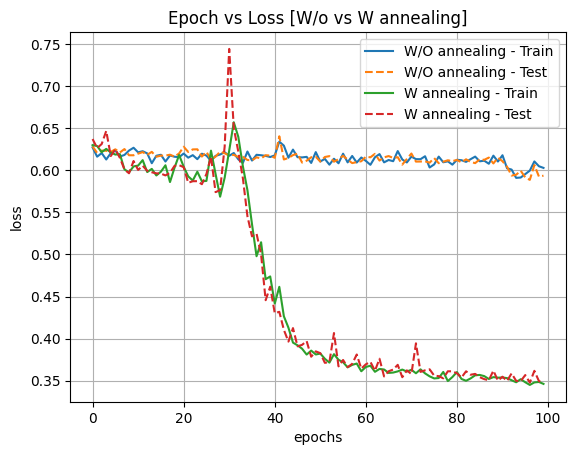

In [47]:
plt.plot(wo_epoch_loss_track, label = "W/O annealing - Train")
plt.plot(wo_epoch_loss_track_test, label = "W/O annealing - Test", linestyle = "--")

plt.plot(w_epoch_loss_track, label = "W annealing - Train")
plt.plot(w_epoch_loss_track_test, label = "W annealing - Test", linestyle = "--")

plt.legend()
plt.xlabel("epochs")
plt.ylabel("loss")

# plt.yscale("log")
# plt.ylim((0, 4))
plt.grid()

plt.title("Epoch vs Loss [W/o vs W annealing]")

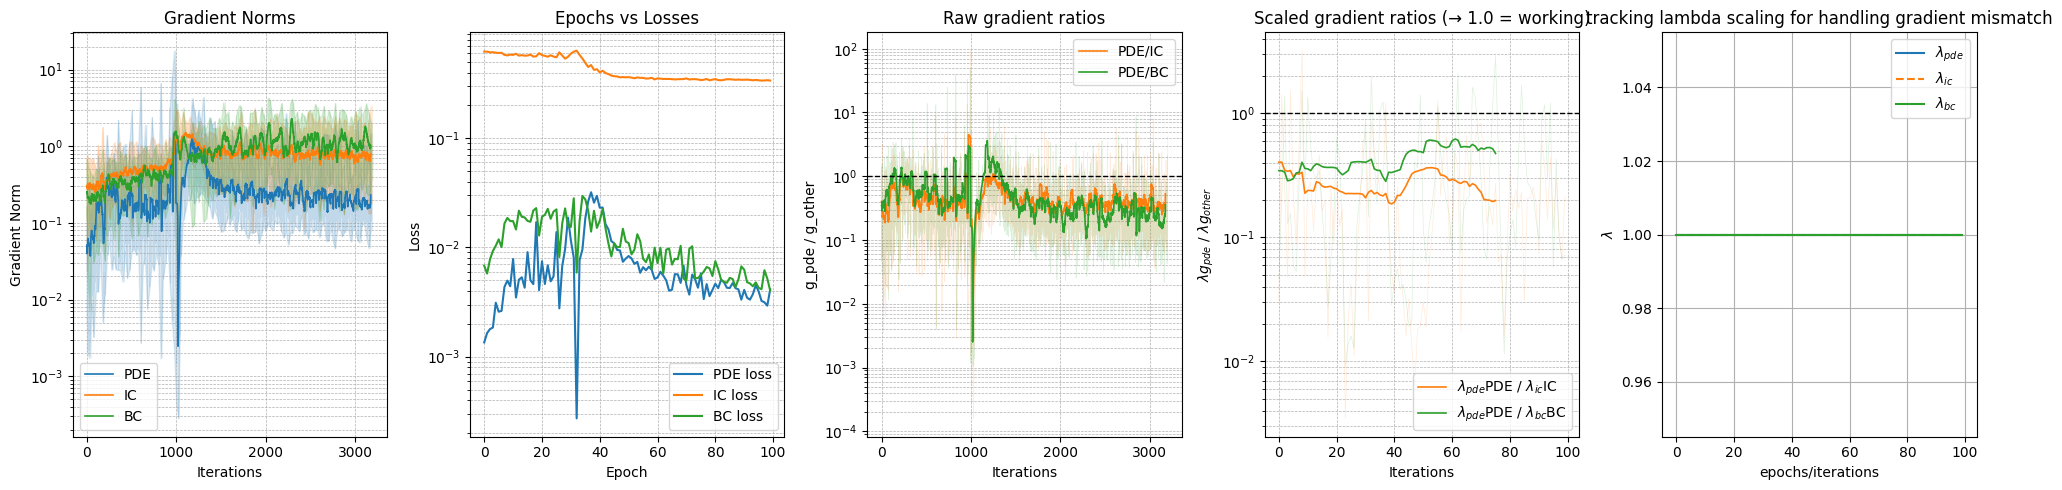

In [48]:
plot_gradients_and_losses(w_grad_tracker, w_residue_tracker, w_lambda_tracker, window=25)

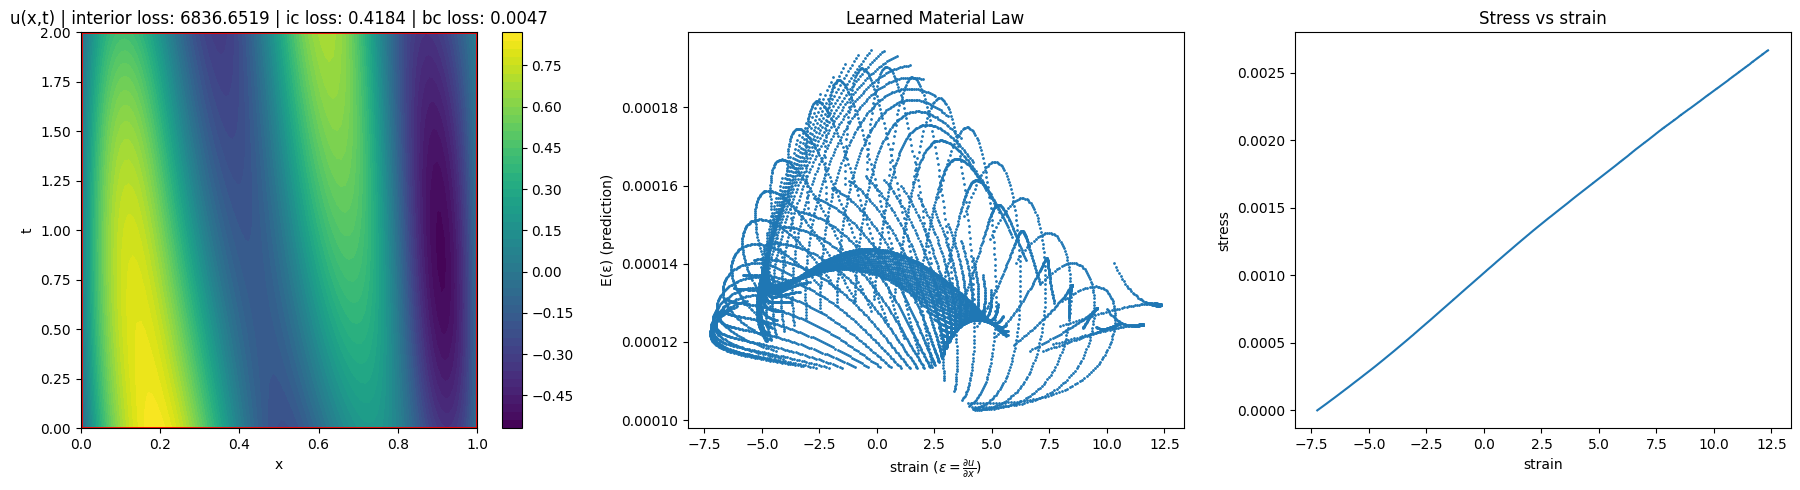

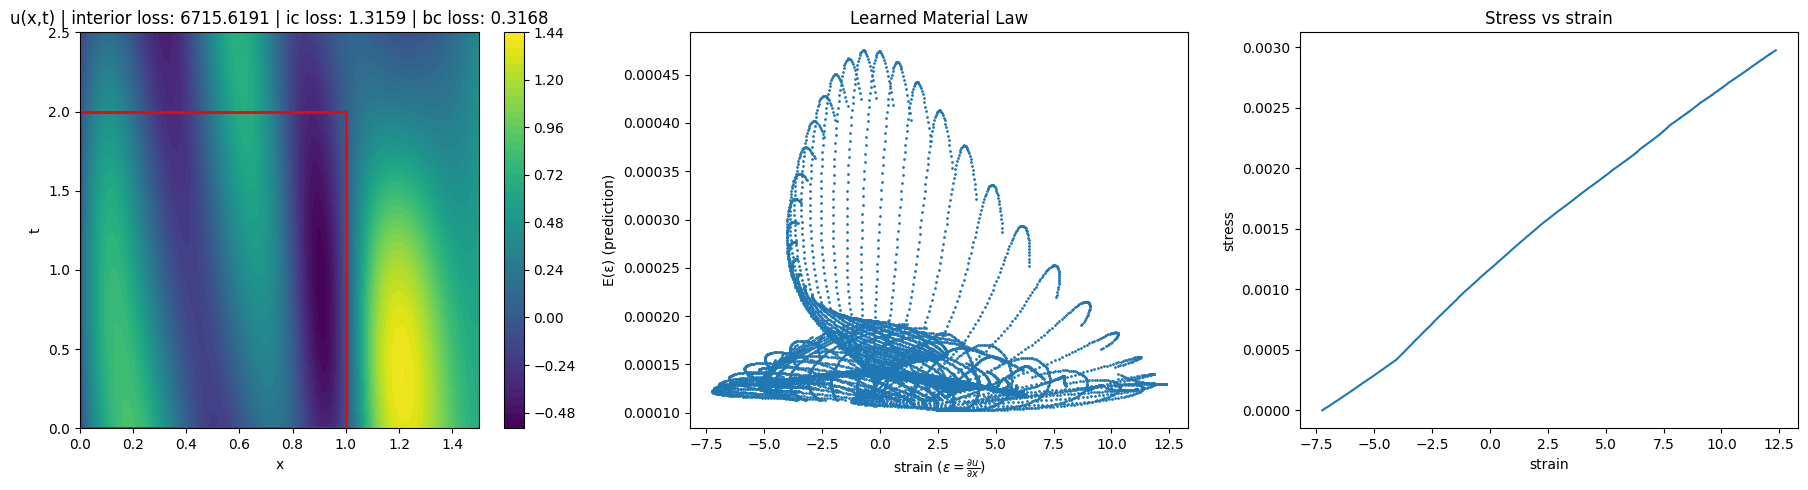

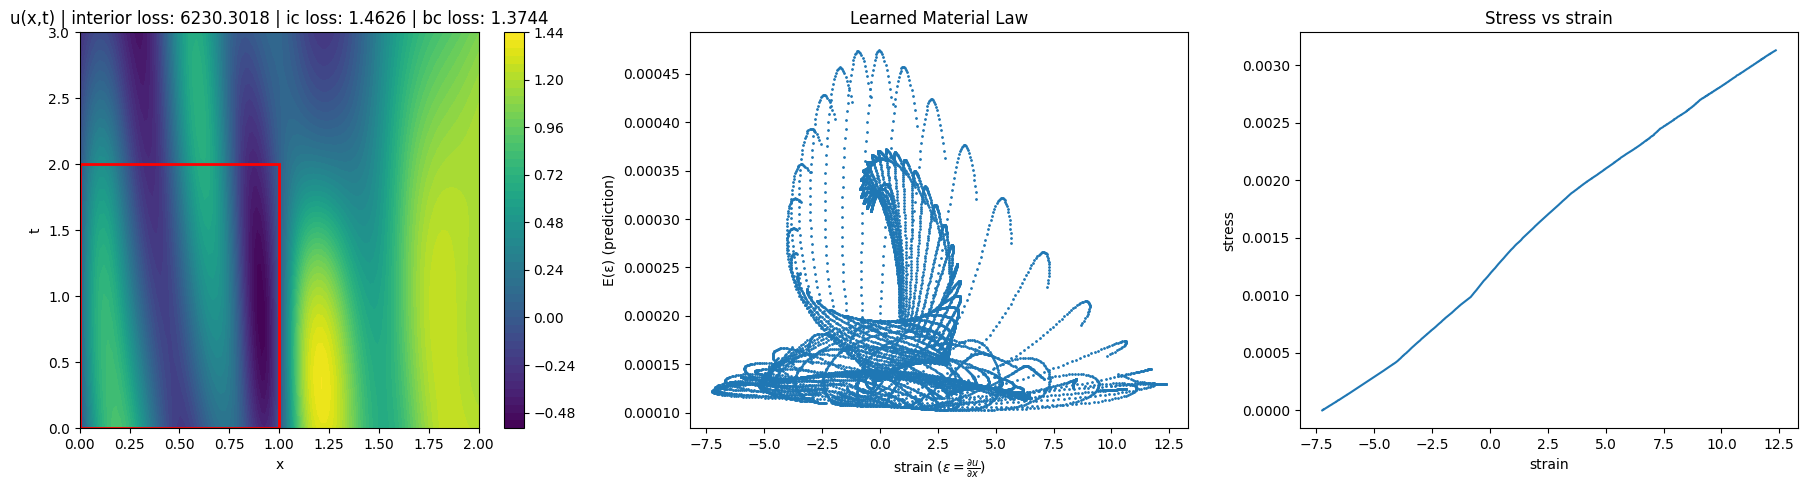

In [54]:
inference(domain = domain, 
          model = w_predictor_model,
          u_0 = u_0, v_0 = v_0)

inference(domain = torch.tensor([[0, 1.5], [0, 2.5]]), 
          model = w_predictor_model,
          u_0 = u_0, v_0 = v_0)

inference(domain = torch.tensor([[0, 2], [0, 3]]), 
          model = w_predictor_model,
          u_0 = u_0, v_0 = v_0)


In [56]:
lr = 1e-4
g_w_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 8, neurons = 180, activation="sin")
g_w_predictor_model.init_siren()

optimizer = torch.optim.Adam(
    g_w_predictor_model.parameters(),
    lr=lr
)

w_g_epoch_loss_track, w_g_epoch_loss_track_test, w_g_residue_tracker, w_g_grad_tracker, w_g_lambda_tracker = train(
                                                                                           epochs = 100, optimizer = optimizer, 
                                                                                           predictor_model = g_w_predictor_model,
                                                                                           train_dataloader = train_dataloader, test_dataloader = test_dataloader, 
                                                                                           get_interior = get_interior, get_initial = get_initial, get_BC = get_BC,
                                                                                           get_interior_residual = get_interior_residual, get_IC_residue = get_IC_residue, get_BC_residue = get_BC_residue, 
                                                                                           domain = domain,
                                                                                           u_0 = u_0, v_0 = v_0,
                                                                                           lr_annealing_decay = True,
                                                                                           initial_lr=lr,
                                                                                           lambda_scaling = True
                                                                                           )

EPOCH: 1 | train loss: 0.6369 | test loss: 0.6471
EPOCH: 11 | train loss: 0.6371 | test loss: 0.6389
EPOCH: 21 | train loss: 0.6316 | test loss: 0.6335
EPOCH: 31 | train loss: 0.6327 | test loss: 0.6368
EPOCH: 41 | train loss: 0.6220 | test loss: 0.6282
EPOCH: 51 | train loss: 0.6293 | test loss: 0.6313
EPOCH: 61 | train loss: 0.6268 | test loss: 0.6366
EPOCH: 71 | train loss: 0.6283 | test loss: 0.6332
EPOCH: 81 | train loss: 0.6284 | test loss: 0.6336
EPOCH: 91 | train loss: 0.6307 | test loss: 0.6382
EPOCH: 100 | train loss: 0.6377 | test loss: 0.6314


In [57]:
w_g_lambda_tracker['pde'][-1], w_g_lambda_tracker['ic'][-1], w_g_lambda_tracker['bc'][-1]

(1.0, 0.9999999655969698, 6.687563970385911)

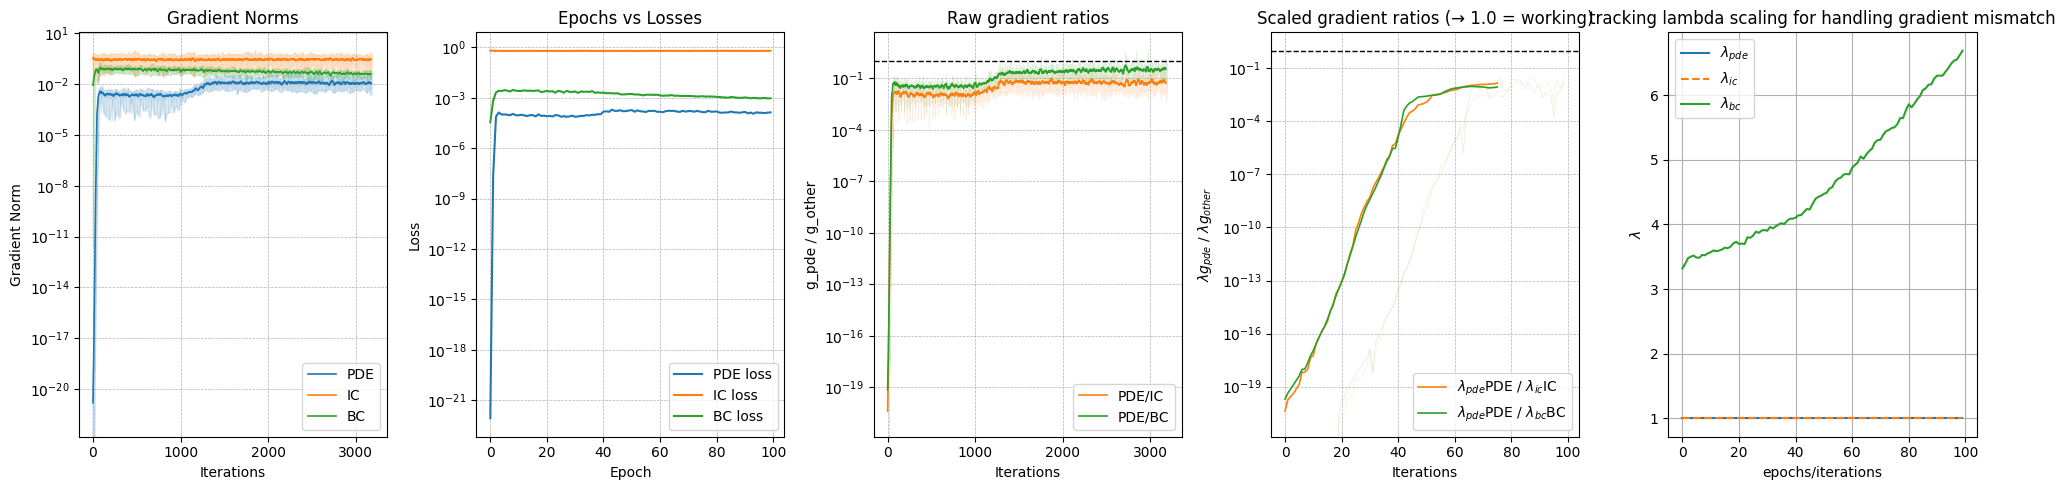

In [58]:
plot_gradients_and_losses(w_g_grad_tracker, w_g_residue_tracker, w_g_lambda_tracker, window=25)

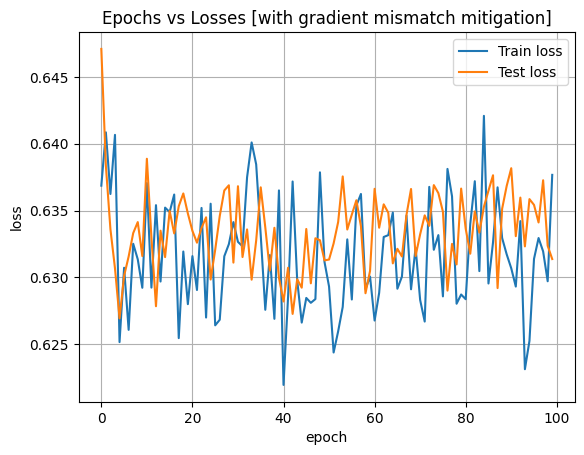

In [59]:
plt.plot(w_g_epoch_loss_track, label = "Train loss")
plt.plot(w_g_epoch_loss_track_test, label = "Test loss")

plt.title("Epochs vs Losses [with gradient mismatch mitigation]")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.grid()
plt.legend()

plt.show()

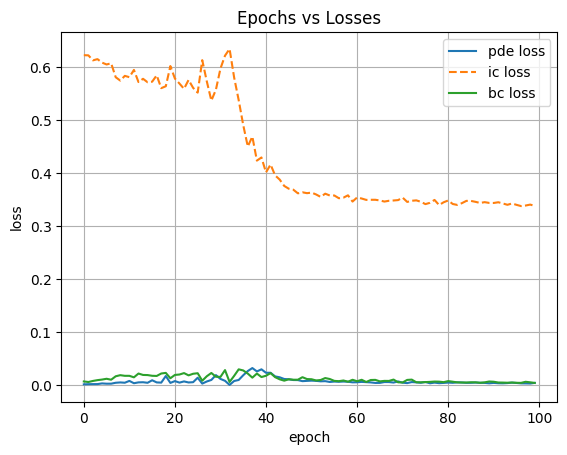

In [60]:
pde_loss = [v[0] for k, v in w_residue_tracker.items()]
ic_loss = [v[1] for k, v in w_residue_tracker.items()]
bc_loss = [v[2] for k, v in w_residue_tracker.items()]

plt.plot(pde_loss, label = "pde loss")
plt.plot(ic_loss, label = "ic loss", linestyle = "--")
plt.plot(bc_loss, label = "bc loss")

plt.title("Epochs vs Losses")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.grid()
plt.legend()

# plt.yscale('log')

plt.show()

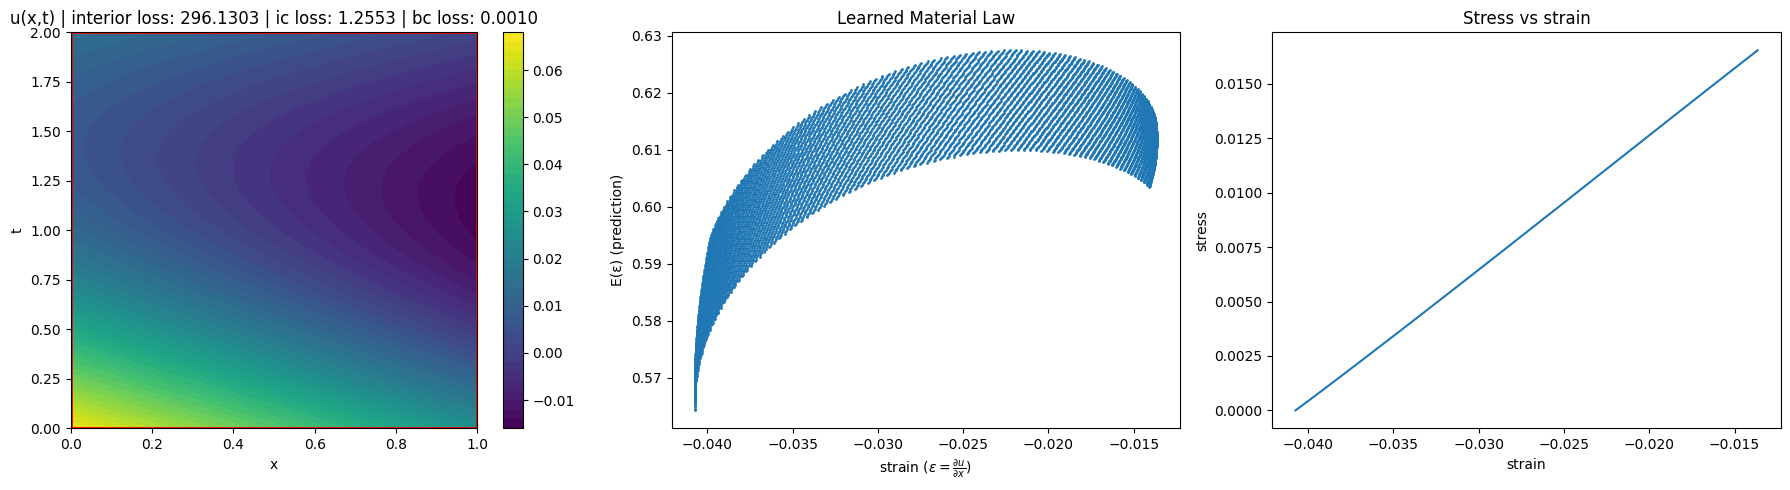

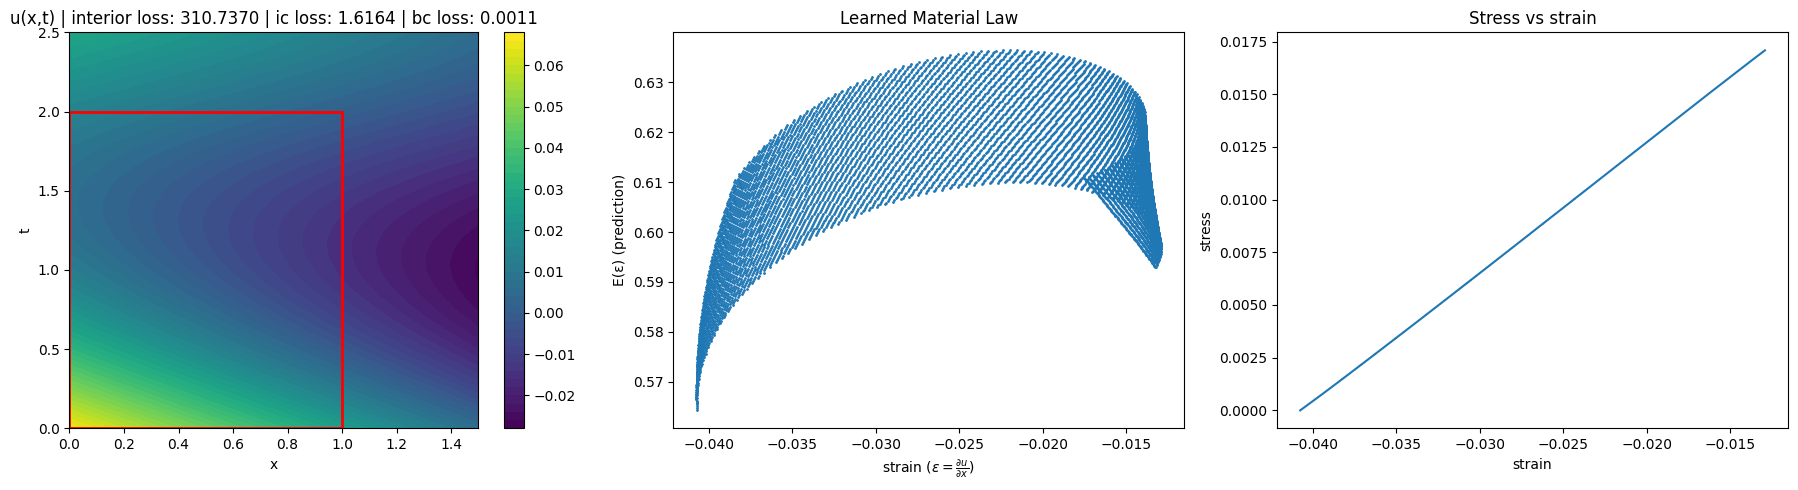

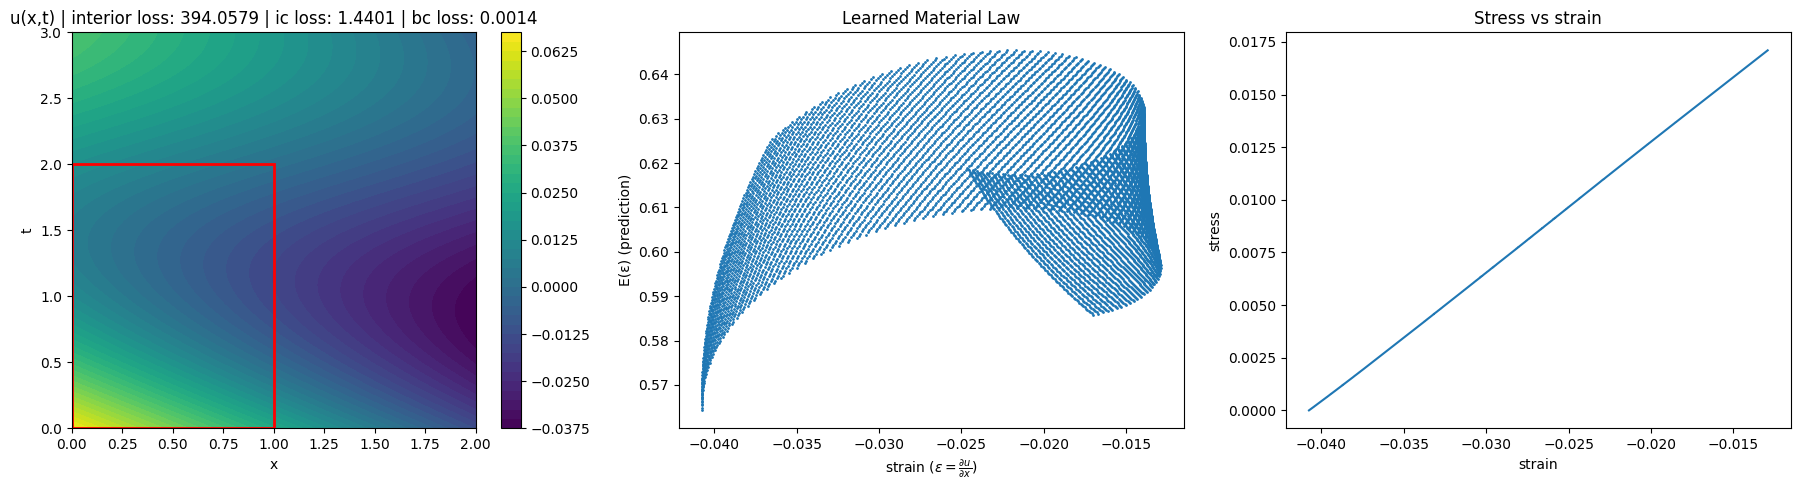

In [61]:
inference(domain = domain, 
          model = g_w_predictor_model,
          u_0 = u_0, v_0 = v_0)

inference(domain = torch.tensor([[0, 1.5], [0, 2.5]]), 
          model = g_w_predictor_model,
          u_0 = u_0, v_0 = v_0)

inference(domain = torch.tensor([[0, 2], [0, 3]]), 
          model = g_w_predictor_model,
          u_0 = u_0, v_0 = v_0)
